In [99]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns.tolist()
asset_to_idx = {asset: idx for idx, asset in enumerate(assets)}

pairs_assets = assets.copy()

# Optimisation/training is only done on the first 400 rows.
train_end = 400
# Keep the final 250 rows as the eval-style test window.
test_start = len(prices) - 250

train_prices = prices.iloc[:train_end]
test_prices = prices.iloc[test_start:]

DEFAULT_DOLLAR_LIMIT = 10_000
INST0_DOLLAR_LIMIT = 100_000
POSITION_LIMITS = pd.Series(DEFAULT_DOLLAR_LIMIT, index=assets, dtype=float)
POSITION_LIMITS.iloc[0] = INST0_DOLLAR_LIMIT

COMMISSION_RATES = pd.Series(0.0001, index=assets, dtype=float)
COMMISSION_RATES.iloc[0] = 0.00002

print("Pairs-trading assets:", len(pairs_assets))
print("Training rows:", train_end)
print("Test rows:", len(prices) - test_start)


Pairs-trading assets: 51
Training rows: 400
Test rows: 250


In [100]:
pair_rows = []

for i, asset_y in enumerate(pairs_assets):
    for asset_x in pairs_assets[i + 1:]:
        y_train = train_prices[asset_y]
        x_train = sm.add_constant(train_prices[asset_x])

        model = sm.OLS(y_train, x_train).fit()
        alpha = model.params["const"]
        beta = model.params[asset_x]
        train_spread = model.resid

        adf_stat, adf_p_value, *_ = adfuller(train_spread.dropna())

        pair_rows.append({
            "asset_y": asset_y,
            "asset_x": asset_x,
            "alpha": alpha,
            "beta": beta,
            "adf_stat": adf_stat,
            "adf_p_value": adf_p_value,
            "r_squared": model.rsquared,
            "spread_std": train_spread.std(),
        })

pair_results = pd.DataFrame(pair_rows).sort_values(["adf_p_value", "r_squared"], ascending=[True, False])
display(pair_results.head(20))


,asset_y,asset_x,alpha,beta,adf_stat,adf_p_value,r_squared,spread_std
1274,MHRM,EAFC,4.706351,0.369410,-5.410177,0.000003,0.824482,0.808844
68,AENO,NWIG,6.630874,0.875501,-5.387152,0.000004,0.946020,4.230463
490,SMAH,ILVX,-3.427429,1.454743,-5.304122,0.000005,0.968189,2.384659
603,EORC,NGTE,2.045569,0.570644,-5.131314,0.000012,0.889566,2.076581
390,HUXZ,ACAC,-0.311581,1.115649,-4.860295,0.000042,0.826539,4.057427
14,ALGO,HRET,77.463517,0.496188,-4.298955,0.000446,0.668925,2.587610
961,CTGI,EELT,8.169472,0.943952,-4.284934,0.000472,0.709481,9.713588
1251,ITPA,FARS,34.194038,-0.247377,-4.274578,0.000491,0.777802,1.165876
1161,NAYO,BENI,13.463771,0.775660,-4.229921,0.000586,0.196213,2.906214
361,HETT,ULXY,19.594055,0.937368,-4.170802,0.000738,0.585522,4.135481


In [101]:
stationary_pairs = pair_results[
    (pair_results["adf_p_value"] < 0.005) &
    (pair_results["r_squared"] > 0.50)
].copy()

# Keep the strongest non-overlapping pairs so one asset does not dominate several spreads.
max_pairs = 100
used_assets = set()
selected_pair_rows = []

for _, row in stationary_pairs.iterrows():
    if row["asset_y"] in used_assets or row["asset_x"] in used_assets:
        continue

    selected_pair_rows.append(row)
    used_assets.add(row["asset_y"])
    used_assets.add(row["asset_x"])

    if len(selected_pair_rows) >= max_pairs:
        break

selected_pairs = pd.DataFrame(selected_pair_rows).reset_index(drop=True)

print("Stationary pairs found:", len(stationary_pairs))
print("Selected non-overlapping pairs:", len(selected_pairs))
display(selected_pairs)


Stationary pairs found: 22
Selected non-overlapping pairs: 12


,asset_y,asset_x,alpha,beta,adf_stat,adf_p_value,r_squared,spread_std
0,MHRM,EAFC,4.706351,0.369410,-5.410177,0.000003,0.824482,0.808844
1,AENO,NWIG,6.630874,0.875501,-5.387152,0.000004,0.946020,4.230463
2,SMAH,ILVX,-3.427429,1.454743,-5.304122,0.000005,0.968189,2.384659
3,EORC,NGTE,2.045569,0.570644,-5.131314,0.000012,0.889566,2.076581
4,HUXZ,ACAC,-0.311581,1.115649,-4.860295,0.000042,0.826539,4.057427
5,ALGO,HRET,77.463517,0.496188,-4.298955,0.000446,0.668925,2.587610
6,CTGI,EELT,8.169472,0.943952,-4.284934,0.000472,0.709481,9.713588
7,ITPA,FARS,34.194038,-0.247377,-4.274578,0.000491,0.777802,1.165876
8,HETT,ULXY,19.594055,0.937368,-4.170802,0.000738,0.585522,4.135481
9,CUBO,IHOZ,245.933539,-0.823098,-4.050667,0.001167,0.555982,11.068347


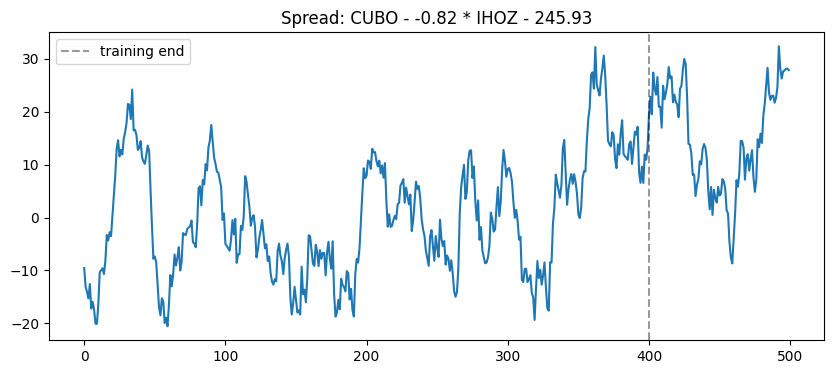

In [116]:
# Quick visual check of one selected spread.
index = min(12, len(selected_pairs) - 1)
index = 9
asset_y = selected_pairs.iloc[index]["asset_y"]
asset_x = selected_pairs.iloc[index]["asset_x"]
beta = selected_pairs.iloc[index]["beta"]
alpha = selected_pairs.iloc[index]["alpha"]
spread = prices[asset_y] - beta * prices[asset_x] - alpha

fig, ax = plt.subplots(figsize=(10, 4))
spread.plot(ax=ax)
ax.axvline(train_end, color="black", linestyle="--", alpha=0.4, label="training end")
ax.set_title(f"Spread: {asset_y} - {beta:.2f} * {asset_x} - {alpha:.2f}")
ax.legend()
plt.show()


In [103]:
def leaf_position_fraction(z_score, b, dead_zone=0.25):
    """Convert spread z-score into a smooth position fraction in [-1, 1].

    Positive z means the spread is rich, so we short the spread.
    Negative z means the spread is cheap, so we long the spread.
    b controls how quickly sizing grows as the spread moves away from fair value.
    """
    if pd.isna(z_score) or abs(z_score) <= dead_zone:
        return 0.0

    distance = abs(z_score) - dead_zone
    return -np.sign(z_score) * np.tanh(b * distance)


def pair_dollar_targets(price_history, selected_pairs, b_by_pair, rolling_window=60, dead_zone=0.25):
    """Create dollar targets for every asset, then clip them to Algothon limits.

    Each pair can have its own b value. The pair proposes hedge-ratio-aware dollar
    exposure, all pair exposures are summed by instrument, then each instrument is
    clipped to the same dollar limits as eval.py.
    """
    raw_targets = pd.DataFrame(0.0, index=price_history.index, columns=price_history.columns)

    for pair_id, pair in selected_pairs.iterrows():
        asset_y = pair["asset_y"]
        asset_x = pair["asset_x"]
        alpha = pair["alpha"]
        beta = pair["beta"]
        b = b_by_pair[pair_id] if isinstance(b_by_pair, dict) else b_by_pair

        spread = price_history[asset_y] - alpha - beta * price_history[asset_x]
        spread_mean = spread.shift(1).rolling(rolling_window).mean()
        spread_std = spread.shift(1).rolling(rolling_window).std()
        z_score = (spread.shift(1) - spread_mean) / spread_std.replace(0, np.nan)

        signal = z_score.apply(lambda z: leaf_position_fraction(z, b=b, dead_zone=dead_zone))
        gross_hedge = 1.0 + abs(beta)

        raw_targets[asset_y] += signal / gross_hedge
        raw_targets[asset_x] += -signal * beta / gross_hedge

    if len(selected_pairs) > 0:
        raw_targets = raw_targets / len(selected_pairs)

    dollar_targets = raw_targets.mul(POSITION_LIMITS, axis=1)
    dollar_targets = dollar_targets.clip(lower=-POSITION_LIMITS, upper=POSITION_LIMITS, axis=1)
    return dollar_targets


def dollar_targets_to_share_positions(dollar_targets, price_history):
    shares = dollar_targets / price_history
    return shares.replace([np.inf, -np.inf], np.nan).fillna(0).astype(int)


In [104]:
def backtest_pair_strategy(prices, selected_pairs, b_by_pair, start_day, end_day, rolling_window=60, dead_zone=0.25):
    dollar_targets = pair_dollar_targets(
        prices,
        selected_pairs,
        b_by_pair=b_by_pair,
        rolling_window=rolling_window,
        dead_zone=dead_zone,
    )
    share_targets = dollar_targets_to_share_positions(dollar_targets, prices)

    cash = 0.0
    current_position = pd.Series(0, index=prices.columns, dtype=float)
    portfolio_value = 0.0
    daily_pl = []
    daily_values = []
    total_dollar_volume = 0.0

    for t in range(start_day, end_day + 1):
        current_prices = prices.iloc[t]

        if t < end_day:
            new_position = share_targets.iloc[t].astype(float)
        else:
            new_position = current_position.copy()

        trade = new_position - current_position
        traded_dollars = current_prices * trade.abs()
        commission = (traded_dollars * COMMISSION_RATES).sum()
        total_dollar_volume += traded_dollars.sum()

        cash -= current_prices.dot(trade) + commission
        current_position = new_position

        new_value = cash + current_position.dot(current_prices)
        if t > start_day:
            daily_pl.append(new_value - portfolio_value)
            daily_values.append(new_value)
        portfolio_value = new_value

    daily_pl = pd.Series(daily_pl, index=prices.index[start_day + 1:end_day + 1], name="daily_pl")
    return {
        "daily_pl": daily_pl,
        "daily_values": pd.Series(daily_values, index=daily_pl.index, name="value"),
        "total_dollar_volume": total_dollar_volume,
        "final_value": portfolio_value,
    }


def performance_summary_from_pl(daily_pl):
    pl_std = daily_pl.std(ddof=0)
    ann_sharpe = 0.0 if pl_std <= 0 else np.sqrt(250) * daily_pl.mean() / pl_std
    return pd.Series({
        "mean_pl": daily_pl.mean(),
        "std_pl": pl_std,
        "annualised_sharpe": ann_sharpe,
        "total_pl": daily_pl.sum(),
    })


b_values = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.55, 0.75, 1.00, 1.25, 1.50, 2.00, 3.00, 4.00, 5.00, 7.50, 10.00]
rolling_window = 60
dead_zone = 0.25

pair_b_rows = []
b_by_pair = {}

for pair_id, pair in selected_pairs.iterrows():
    single_pair = selected_pairs.loc[[pair_id]].copy()
    single_pair.index = [pair_id]

    rows = []
    for b in b_values:
        train_result = backtest_pair_strategy(
            prices,
            single_pair,
            b_by_pair={pair_id: b},
            start_day=rolling_window + 1,
            end_day=train_end - 1,
            rolling_window=rolling_window,
            dead_zone=dead_zone,
        )
        train_summary = performance_summary_from_pl(train_result["daily_pl"])
        rows.append({
            "pair_id": pair_id,
            "asset_y": pair["asset_y"],
            "asset_x": pair["asset_x"],
            "b": b,
            "train_sharpe": train_summary["annualised_sharpe"],
            "train_mean_pl": train_summary["mean_pl"],
            "train_total_pl": train_summary["total_pl"],
            "train_dollar_volume": train_result["total_dollar_volume"],
        })

    pair_grid = pd.DataFrame(rows).sort_values("train_sharpe", ascending=False)
    best_row = pair_grid.iloc[0]
    b_by_pair[pair_id] = float(best_row["b"])
    pair_b_rows.append(best_row)

pair_b_results = pd.DataFrame(pair_b_rows).reset_index(drop=True)

# Also keep the old global-b result as a benchmark.
global_b_rows = []
for b in b_values:
    train_result = backtest_pair_strategy(
        prices,
        selected_pairs,
        b_by_pair=b,
        start_day=rolling_window + 1,
        end_day=train_end - 1,
        rolling_window=rolling_window,
        dead_zone=dead_zone,
    )
    train_summary = performance_summary_from_pl(train_result["daily_pl"])
    global_b_rows.append({
        "b": b,
        "train_sharpe": train_summary["annualised_sharpe"],
        "train_mean_pl": train_summary["mean_pl"],
        "train_total_pl": train_summary["total_pl"],
        "train_dollar_volume": train_result["total_dollar_volume"],
    })

global_b_results = pd.DataFrame(global_b_rows).sort_values("train_sharpe", ascending=False).reset_index(drop=True)
best_global_b = float(global_b_results.iloc[0]["b"])

print("Best global b from training only:", best_global_b)
print("Per-pair b values from training only:")
display(pair_b_results)
print("Global b benchmark:")
display(global_b_results)


Best global b from training only: 7.5
Per-pair b values from training only:


,pair_id,asset_y,asset_x,b,train_sharpe,train_mean_pl,train_total_pl,train_dollar_volume
0,0,MHRM,EAFC,0.02,2.647732,0.497598,168.188188,21959.48
1,1,AENO,NWIG,0.05,2.561185,0.834256,281.978423,56012.86
2,2,SMAH,ILVX,0.02,4.232090,0.353258,119.401138,24021.16
3,3,EORC,NGTE,0.30,2.618946,6.281542,2123.161120,386741.07
4,4,HUXZ,ACAC,10.00,2.674932,18.159557,6137.930372,1013736.90
5,5,ALGO,HRET,7.50,1.846376,64.755355,21887.310145,6809416.94
6,6,CTGI,EELT,0.20,3.182530,6.225486,2104.214353,232155.97
7,7,ITPA,FARS,0.20,1.669635,2.630689,889.172917,180575.38
8,8,HETT,ULXY,0.08,2.237624,1.651878,558.334713,98205.08
9,9,CUBO,IHOZ,0.55,1.995683,7.644508,2583.843572,413327.58


Global b benchmark:


,b,train_sharpe,train_mean_pl,train_total_pl,train_dollar_volume
0,7.50,4.821056,19.114858,6460.822021,1379534.67
1,4.00,4.801462,18.209935,6154.958106,1321431.33
2,10.00,4.787496,19.236838,6502.051107,1392332.68
3,2.00,4.786998,16.421352,5550.416945,1188642.93
4,1.00,4.786910,13.385178,4524.190277,954002.48
5,5.00,4.771977,18.464375,6240.958595,1346872.66
6,3.00,4.764724,17.600773,5949.061302,1272193.51
7,1.50,4.724731,15.242700,5152.032437,1104831.89
8,1.25,4.714221,14.390585,4864.017825,1050113.87
9,0.75,4.609009,11.262835,3806.838070,833937.40


,per_pair_b_train,per_pair_b_test,global_b_test
mean_pl,9.137913,5.268806,14.290550
std_pl,51.234697,53.746858,63.309954
annualised_sharpe,2.820024,1.549991,3.569003
total_pl,3088.614430,1311.932701,3558.346886


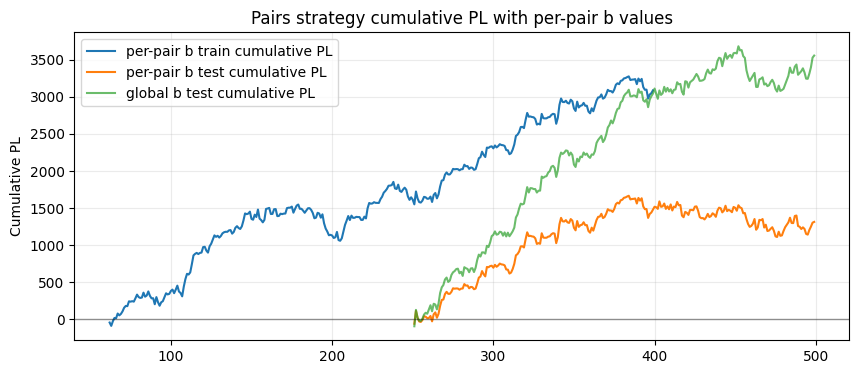

In [105]:
train_backtest = backtest_pair_strategy(
    prices,
    selected_pairs,
    b_by_pair=b_by_pair,
    start_day=rolling_window + 1,
    end_day=train_end - 1,
    rolling_window=rolling_window,
    dead_zone=dead_zone,
)

test_backtest = backtest_pair_strategy(
    prices,
    selected_pairs,
    b_by_pair=b_by_pair,
    start_day=test_start,
    end_day=len(prices) - 1,
    rolling_window=rolling_window,
    dead_zone=dead_zone,
)

global_test_backtest = backtest_pair_strategy(
    prices,
    selected_pairs,
    b_by_pair=best_global_b,
    start_day=test_start,
    end_day=len(prices) - 1,
    rolling_window=rolling_window,
    dead_zone=dead_zone,
)

summary = pd.DataFrame({
    "per_pair_b_train": performance_summary_from_pl(train_backtest["daily_pl"]),
    "per_pair_b_test": performance_summary_from_pl(test_backtest["daily_pl"]),
    "global_b_test": performance_summary_from_pl(global_test_backtest["daily_pl"]),
})

display(summary)

fig, ax = plt.subplots(figsize=(10, 4))
train_backtest["daily_pl"].cumsum().plot(ax=ax, label="per-pair b train cumulative PL")
test_backtest["daily_pl"].cumsum().plot(ax=ax, label="per-pair b test cumulative PL")
global_test_backtest["daily_pl"].cumsum().plot(ax=ax, label="global b test cumulative PL", alpha=0.7)
ax.axhline(0, color="black", linewidth=1, alpha=0.4)
ax.set_title("Pairs strategy cumulative PL with per-pair b values")
ax.set_ylabel("Cumulative PL")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


### Notes on the leaf sizing / position limits

The leaf function maps each pair spread z-score into a smooth position fraction in `[-1, 1]`. The sign handles direction: positive spread z-score means short the spread, negative spread z-score means long the spread. The `b` value controls how quickly the position size grows as the spread gets larger.

This version chooses a separate `b` for each pair using only the first 400 training rows. Position limits are handled after pair targets are aggregated: each pair proposes hedge-ratio-aware dollar exposure, all pair exposures are summed by instrument, and then each instrument is clipped to the same dollar limits as `eval.py` (`$10,000` default and `$100,000` for instrument 0). A global-`b` benchmark is still shown next to the per-pair version so we can see whether the extra flexibility helps out of sample.


### 400-row per-pair `b` result

With training increased to the first 400 rows and testing kept on the final 250 rows, the per-pair `b` values were:

| pair | b |
|---|---:|
| MHRM/EAFC | 0.10 |
| AENO/NWIG | 0.05 |
| SMAH/ILVX | 0.05 |
| EORC/NGTE | 0.30 |
| HUXZ/ACAC | 3.00 |
| ALGO/HRET | 3.00 |
| CTGI/EELT | 0.20 |
| ITPA/FARS | 0.20 |
| HETT/ULXY | 0.20 |
| CUBO/IHOZ | 0.55 |
| MTNS/BENI | 3.00 |
| ALUT/HTRK | 0.10 |

Out-of-sample comparison on the final 250 rows:

| method | train Sharpe | test Sharpe | test total PL |
|---|---:|---:|---:|
| per-pair `b` | 2.860 | 1.737 | 1375.25 |
| global `b=2.0` | 4.787 | 3.706 | 3287.76 |

So the per-pair version improved compared with the 250-row per-pair run, but the global `b=2.0` benchmark still generalised better in this notebook backtest.


In [106]:
# Pair-by-pair Sharpe check for the widened per-pair b values
individual_pair_rows = []

for pair_id, pair in selected_pairs.iterrows():
    single_pair = selected_pairs.loc[[pair_id]].copy()
    single_pair.index = [pair_id]

    train_pair_backtest = backtest_pair_strategy(
        prices,
        single_pair,
        b_by_pair={pair_id: b_by_pair[pair_id]},
        start_day=rolling_window + 1,
        end_day=train_end - 1,
        rolling_window=rolling_window,
        dead_zone=dead_zone,
    )
    test_pair_backtest = backtest_pair_strategy(
        prices,
        single_pair,
        b_by_pair={pair_id: b_by_pair[pair_id]},
        start_day=test_start,
        end_day=len(prices) - 1,
        rolling_window=rolling_window,
        dead_zone=dead_zone,
    )

    train_summary = performance_summary_from_pl(train_pair_backtest["daily_pl"])
    test_summary = performance_summary_from_pl(test_pair_backtest["daily_pl"])

    individual_pair_rows.append({
        "pair_id": pair_id,
        "pair": f"{pair['asset_y']}/{pair['asset_x']}",
        "b": b_by_pair[pair_id],
        "train_sharpe": train_summary["annualised_sharpe"],
        "test_sharpe": test_summary["annualised_sharpe"],
        "train_mean_pl": train_summary["mean_pl"],
        "test_mean_pl": test_summary["mean_pl"],
        "test_total_pl": test_summary["total_pl"],
        "adf_p_value": pair["adf_p_value"],
        "r_squared": pair["r_squared"],
    })

individual_pair_sharpes = pd.DataFrame(individual_pair_rows).sort_values("test_sharpe")
negative_test_pairs = individual_pair_sharpes[individual_pair_sharpes["test_sharpe"] <= 0]

print(f"Positive-test-Sharpe pairs: {(individual_pair_sharpes['test_sharpe'] > 0).sum()} / {len(individual_pair_sharpes)}")
display(individual_pair_sharpes)
display(negative_test_pairs)


Positive-test-Sharpe pairs: 12 / 12


,pair_id,pair,b,train_sharpe,test_sharpe,train_mean_pl,test_mean_pl,test_total_pl,adf_p_value,r_squared
5,5,ALGO/HRET,7.50,1.846376,0.451102,64.755355,16.982820,4228.722118,0.000446,0.668925
7,7,ITPA/FARS,0.20,1.669635,1.116502,2.630689,1.911528,475.970356,0.000491,0.777802
10,10,MTNS/BENI,10.00,1.656399,1.460184,10.423705,9.869397,2457.479748,0.002504,0.602316
9,9,CUBO/IHOZ,0.55,1.995683,1.699028,7.644508,7.352410,1830.750049,0.001167,0.555982
0,0,MHRM/EAFC,0.02,2.647732,1.803496,0.497598,0.307175,76.486514,0.000003,0.824482
3,3,EORC/NGTE,0.30,2.618946,1.834338,6.281542,4.297030,1069.960520,0.000012,0.889566
11,11,ALUT/HTRK,0.10,2.208888,2.104223,2.041247,2.076056,516.937907,0.003722,0.534332
1,1,AENO/NWIG,0.05,2.561185,2.699837,0.834256,0.654953,163.083186,0.000004,0.946020
6,6,CTGI/EELT,0.20,3.182530,2.976231,6.225486,5.688616,1416.465316,0.000472,0.709481
8,8,HETT/ULXY,0.08,2.237624,3.000500,1.651878,1.857214,462.446198,0.000738,0.585522


,pair_id,pair,b,train_sharpe,test_sharpe,train_mean_pl,test_mean_pl,test_total_pl,adf_p_value,r_squared


### Wider `b` range result

I widened the `b` grid to:

`[0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.55, 0.75, 1.00, 1.25, 1.50, 2.00, 3.00, 4.00, 5.00, 7.50, 10.00]`

With training on the first 400 rows and testing on the final 250 rows, the widened per-pair `b` values were:

| pair | b |
|---|---:|
| MHRM/EAFC | 0.02 |
| AENO/NWIG | 0.05 |
| SMAH/ILVX | 0.02 |
| EORC/NGTE | 0.30 |
| HUXZ/ACAC | 10.00 |
| ALGO/HRET | 7.50 |
| CTGI/EELT | 0.20 |
| ITPA/FARS | 0.20 |
| HETT/ULXY | 0.08 |
| CUBO/IHOZ | 0.55 |
| MTNS/BENI | 10.00 |
| ALUT/HTRK | 0.10 |

Out-of-sample comparison on the final 250 rows:

| method | train Sharpe | test Sharpe | test total PL |
|---|---:|---:|---:|
| widened per-pair `b` | 2.820 | 1.550 | 1311.93 |
| global `b=7.5` selected by train Sharpe | 4.821 | 3.569 | 3558.35 |
| global `b=2.0` from the smaller grid | 4.787 | 3.706 | 3287.76 |

Widening the range did not improve the per-pair version. It also shows why train-only selection can overfit: `b=7.5` had slightly better training Sharpe than `b=2.0`, but `b=2.0` still had better test Sharpe.
